In [1]:
print('test')

test


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./dataset/hotel_booking.csv', encoding='utf-8')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [125]:
df2 = df.copy()

In [126]:
# children의 결측치는 0으로 처리 후 정수형으로 바꿈
df2["children"] = df2["children"].fillna(0).astype(int)

In [127]:
# 투숙객 0명 값 제거
df2 = df2[
    (df2["adults"] + df2["children"] + df2["babies"]) > 0
]

print("제거 후 데이터 크기:", df2.shape)

제거 후 데이터 크기: (119210, 36)


In [128]:
# children / babies 극단값 제거
df2 = df2[
    (df2["children"] < 5) &
    (df2["babies"] < 5)
]

print("제거 후 데이터 크기:", df2.shape)

제거 후 데이터 크기: (119207, 36)


In [129]:
# 파생변수 : 성인+아동+영아 -> 투숙객 수 
df2["total_guests"] = (
    df2["adults"]
    + df2["children"]
    + df2["babies"]
)

# 파생변수 : 아이 동반
df2["has_children"] = (
    (df2["children"] + df2["babies"]) > 0
).astype(int)

# 원본 제거
df2 = df2.drop(columns=["adults", "children", "babies"])

In [130]:
# agent / company는 ID 대신 이용 여부 변수 생성
df2["has_agent"] = df2["agent"].notna().astype(int)
df2["has_company"] = df2["company"].notna().astype(int)

# 원본 제거
df2 = df2.drop(columns=["agent", "company"])

In [131]:
# 총 숙박일수
df2["total_nights"] = (
    df2["stays_in_weekend_nights"]
    + df2["stays_in_week_nights"]
)

# 주말 포함 여부
df2["has_weekend_stay"] = (
    df2["stays_in_weekend_nights"] > 0
).astype(int)

In [132]:
# 숙박일수 0 제거 및 관련 컬럼 삭제
df2 = df2[df2["total_nights"] > 0]
print("0박 예약 제거 후 데이터 크기:", df2.shape)

df2 = df2.drop(
    columns=[
        "stays_in_weekend_nights",
        "stays_in_week_nights",
        "has_weekend_stay"
    ]
)

0박 예약 제거 후 데이터 크기: (118562, 37)


In [133]:
print("남은 0박 예약:", (df2["total_nights"] == 0).sum())

남은 0박 예약: 0


In [ ]:
# 파생컬럼 : 예약 대기시간 유무
df2["has_waiting_list"] = (df2["days_in_waiting_list"] > 0).astype(int)

# 관련 컬럼 삭제
df2 = df2.drop(
    columns=["days_in_waiting_list"]
)

In [ ]:
# country 결측치 처리 : unknown
df2["country"] = df2["country"].fillna("Unknown")

In [135]:
# 178개국 -> 상위 10개 + other 로 정리
top_countries = (
    df2["country"]
    .value_counts()
    .head(10)
    .index
)

df2["country_group"] = df2["country"].where(
    df2["country"].isin(top_countries),
    "Other"
)

# 관련 컬럼 삭제
df2 = df2.drop(columns=["country"])

In [ ]:
# 제거해야 할 컬럼
drop_cols=['name', 'email', 'phone-number', 'credit_card', 
           'reservation_status', 'reservation_status_date', 'assigned_room_type',
           'arrival_date_day_of_month', 'arrival_date_week_number',
           'arrival_date_year', 'booking_changes', 'distribution_channel', 'deposit_type']

df2 = df2.drop(columns=drop_cols)

In [155]:
print("데이터 크기:", df2.shape)
print("컬럼명:", df2.columns)

데이터 크기: (118562, 21)
컬럼명: Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_month', 'meal',
       'market_segment', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type', 'customer_type',
       'adr', 'required_car_parking_spaces', 'total_of_special_requests',
       'total_guests', 'has_children', 'has_agent', 'has_company',
       'total_nights', 'has_waiting_list', 'country_group'],
      dtype='str')


In [142]:
df2.info()

<class 'pandas.DataFrame'>
Index: 118562 entries, 2 to 119389
Data columns (total 21 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118562 non-null  str    
 1   is_canceled                     118562 non-null  int64  
 2   lead_time                       118562 non-null  int64  
 3   arrival_date_month              118562 non-null  str    
 4   meal                            118562 non-null  str    
 5   market_segment                  118562 non-null  str    
 6   is_repeated_guest               118562 non-null  int64  
 7   previous_cancellations          118562 non-null  int64  
 8   previous_bookings_not_canceled  118562 non-null  int64  
 9   reserved_room_type              118562 non-null  str    
 10  customer_type                   118562 non-null  str    
 11  adr                             118562 non-null  float64
 12  required_car_parking_spaces     

In [144]:
# 결측치가 있는 컬럼만 확인
null_count = df2.isnull().sum()
print(null_count[null_count > 0])

Series([], dtype: int64)


In [145]:
print("df2 중복 데이터 수:", df2.duplicated().sum())
print("df 중복 데이터 수:", df.duplicated().sum())

df2 중복 데이터 수: 34807
df 중복 데이터 수: 0


In [147]:
# 수치형 컬럼 수 정리
numeric_df = df2.select_dtypes(include="number")

print(numeric_df.columns)
print("수치형 컬럼 수:", len(numeric_df.columns))

Index(['is_canceled', 'lead_time', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'total_guests', 'has_children', 'has_agent', 'has_company',
       'total_nights', 'has_waiting_list'],
      dtype='str')
수치형 컬럼 수: 14


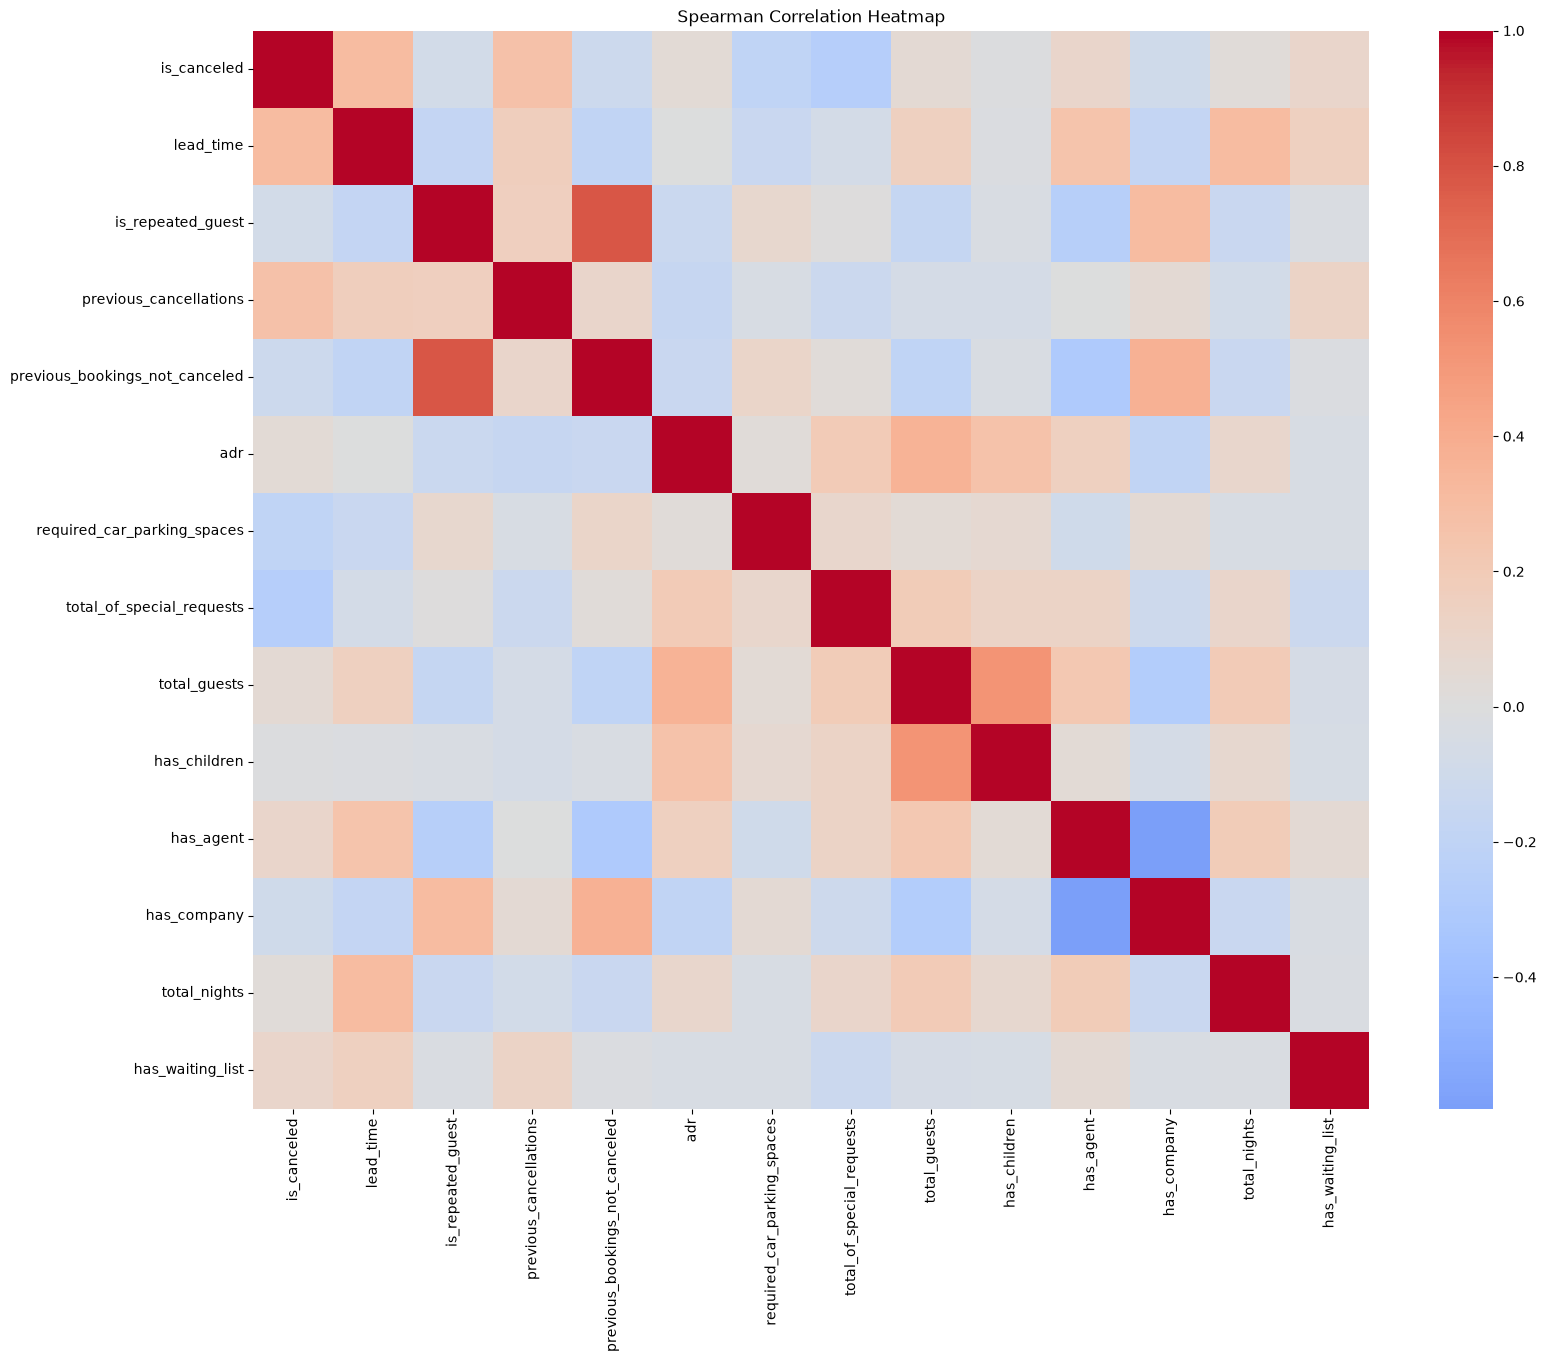

In [148]:
plt.figure(figsize=(18, 14))

corr = numeric_df.corr(method="spearman")

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Spearman Correlation Heatmap")
plt.show()

In [150]:
cancel_corr = (
    corr["is_canceled"]
    .drop("is_canceled")
    .sort_values(key=abs, ascending=False)
)

cancel_corr

lead_time                         0.314588
previous_cancellations            0.270107
total_of_special_requests        -0.260177
required_car_parking_spaces      -0.198726
previous_bookings_not_canceled   -0.115706
has_agent                         0.101080
has_company                      -0.099721
has_waiting_list                  0.098765
is_repeated_guest                -0.077793
total_guests                      0.049323
adr                               0.043862
total_nights                      0.030425
has_children                     -0.013201
Name: is_canceled, dtype: float64

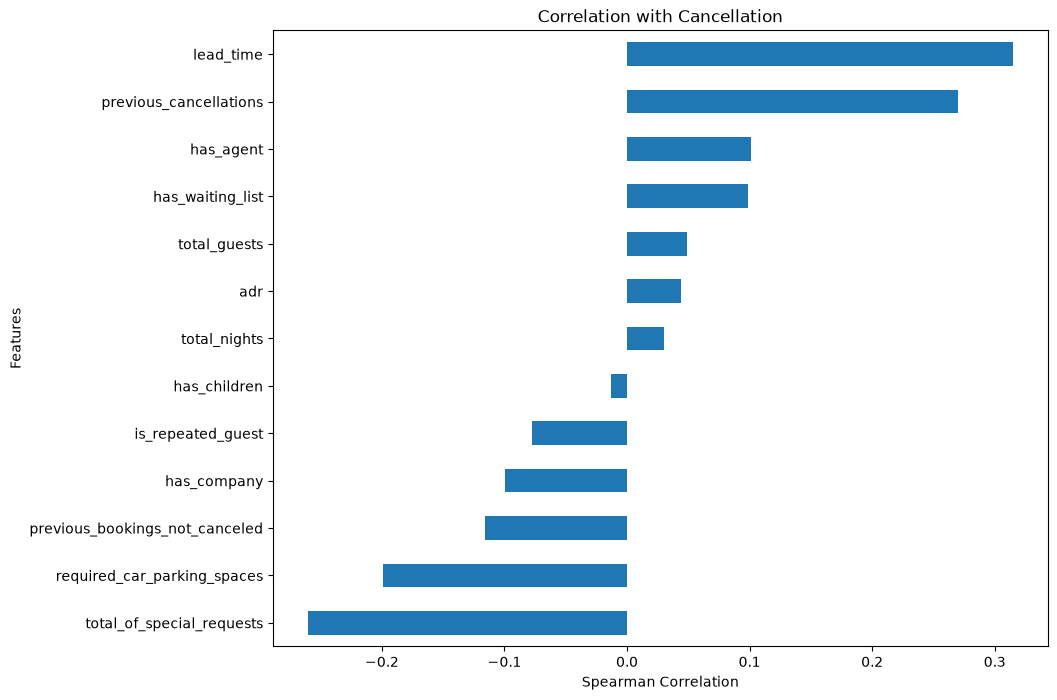

In [151]:
plt.figure(figsize=(10, 8))

cancel_corr.sort_values().plot(kind="barh")

plt.title("Correlation with Cancellation")
plt.xlabel("Spearman Correlation")
plt.ylabel("Features")
plt.show()

In [109]:
categorical_cols = [
    "hotel",
    "arrival_date_month",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "deposit_type",
    "customer_type"
]

In [110]:
for col in categorical_cols:
    print(f"{col}: {df2[col].nunique()}개")

hotel: 2개
arrival_date_month: 12개
meal: 5개
country: 178개
market_segment: 8개
distribution_channel: 5개
reserved_room_type: 9개
deposit_type: 3개
customer_type: 4개


In [111]:
for col in categorical_cols:
    if col == "country":
        continue

    print(f"\n===== {col} =====")

    result = (
        df2.groupby(col)["is_canceled"]
        .agg(["count", "mean"])
        .sort_values("count", ascending=False)
    )

    display(result)


===== hotel =====


,count,mean
hotel,,
City Hotel,78897,0.419103
Resort Hotel,39665,0.280071



===== arrival_date_month =====


,count,mean
arrival_date_month,,
August,13812,0.379163
July,12585,0.376242
May,11704,0.399436
October,11063,0.383711
April,11045,0.408782
June,10891,0.416123
September,10477,0.392670
March,9716,0.323796
February,7998,0.335834



===== meal =====


...

,count,mean
reserved_room_type,,
A,85397,0.393538
D,19094,0.319315
E,6482,0.294199
F,2879,0.305662
G,2074,0.367888
B,1110,0.330631
C,923,0.332611
H,597,0.410385
L,6,0.333333



===== deposit_type =====


,count,mean
deposit_type,,
No Deposit,103813,0.285562
Non Refund,14587,0.993624
Refundable,162,0.222222



===== customer_type =====


,count,mean
customer_type,,
Transient,88934,0.410113
Transient-Party,25004,0.255279
Contract,4055,0.310974
Group,569,0.101933


In [112]:
print("국가 개수:", df2["country"].nunique())

df2["country"].value_counts().head(20)

국가 개수: 178


country
PRT    47941
GBR    12094
FRA    10389
ESP     8544
DEU     7285
ITA     3756
IRL     3373
BEL     2338
BRA     2217
NLD     2101
USA     2089
CHE     1724
CN      1278
AUT     1262
SWE     1019
CHN      998
POL      915
ISR      669
RUS      627
NOR      606
Name: count, dtype: int64

### 머신러닝 시작

In [153]:
categorical_cols = [
    "hotel",
    "arrival_date_month",
    "meal",
    "market_segment",
    "reserved_room_type",
    "customer_type",
    "country_group"
]

numeric_cols = [
    "lead_time",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "has_agent",
    "has_company",
    "total_guests",
    "total_nights",
    "has_waiting_list",
    "has_children"
]

feature_cols = categorical_cols + numeric_cols

In [154]:
print("Feature 수:", len(feature_cols))
print(feature_cols)

Feature 수: 20
['hotel', 'arrival_date_month', 'meal', 'market_segment', 'reserved_room_type', 'customer_type', 'country_group', 'lead_time', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'has_agent', 'has_company', 'total_guests', 'total_nights', 'has_waiting_list', 'has_children']


In [157]:
# 학습 데이터 분리
X = df2[feature_cols]
y = df2["is_canceled"]

In [158]:
print("X:", X.shape)
print("y:", y.shape)

print("\nTarget 분포")
print(y.value_counts())
print(y.value_counts(normalize=True))

X: (118562, 20)
y: (118562,)

Target 분포
is_canceled
0    74387
1    44175
Name: count, dtype: int64
is_canceled
0    0.62741
1    0.37259
Name: proportion, dtype: float64


In [160]:
# Train / Test 분리
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [161]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\n전체 취소율")
print(y.mean())

print("Train 취소율")
print(y_train.mean())

print("Test 취소율")
print(y_test.mean())

X_train: (94849, 20)
X_test : (23713, 20)

전체 취소율
0.3725898685919603
Train 취소율
0.3725922255374332
Test 취소율
0.37258044110825284


In [162]:
# One-Hot Encoding + Scaling 준비

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
# 범주형
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [164]:
# 수치형
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

In [165]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [166]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("변환 전 X_train:", X_train.shape)
print("변환 후 X_train:", X_train_processed.shape)

print("변환 전 X_test:", X_test.shape)
print("변환 후 X_test:", X_test_processed.shape)

변환 전 X_train: (94849, 20)
변환 후 X_train: (94849, 64)
변환 전 X_test: (23713, 20)
변환 후 X_test: (23713, 64)


In [167]:
processed_feature_names = (
    preprocessor.get_feature_names_out()
)

print("전처리 후 Feature 수:", len(processed_feature_names))
print(processed_feature_names)

전처리 후 Feature 수: 64
['num__lead_time' 'num__is_repeated_guest' 'num__previous_cancellations'
 'num__previous_bookings_not_canceled' 'num__adr'
 'num__required_car_parking_spaces' 'num__total_of_special_requests'
 'num__has_agent' 'num__has_company' 'num__total_guests'
 'num__total_nights' 'num__has_waiting_list' 'num__has_children'
 'cat__hotel_City Hotel' 'cat__hotel_Resort Hotel'
 'cat__arrival_date_month_April' 'cat__arrival_date_month_August'
 'cat__arrival_date_month_December' 'cat__arrival_date_month_February'
 'cat__arrival_date_month_January' 'cat__arrival_date_month_July'
 'cat__arrival_date_month_June' 'cat__arrival_date_month_March'
 'cat__arrival_date_month_May' 'cat__arrival_date_month_November'
 'cat__arrival_date_month_October' 'cat__arrival_date_month_September'
 'cat__meal_BB' 'cat__meal_FB' 'cat__meal_HB' 'cat__meal_SC'
 'cat__meal_Undefined' 'cat__market_segment_Aviation'
 'cat__market_segment_Complementary' 'cat__market_segment_Corporate'
 'cat__market_segment_Direc

In [168]:
# Pipeline + Logistic Regression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [170]:
lr_pipeline.fit(X_train, y_train)
y_pred = lr_pipeline.predict(X_test)
y_proba = lr_pipeline.predict_proba(X_test)[:, 1]

In [171]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.802
Precision: 0.7742
Recall   : 0.6613
F1 Score : 0.7133
ROC-AUC  : 0.8772

Confusion Matrix
[[13174  1704]
 [ 2992  5843]]


In [172]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85     14878
           1       0.77      0.66      0.71      8835

    accuracy                           0.80     23713
   macro avg       0.79      0.77      0.78     23713
weighted avg       0.80      0.80      0.80     23713



In [173]:
import pandas as pd

model_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.8020,
        "Precision": 0.7742,
        "Recall": 0.6613,
        "F1 Score": 0.7133,
        "ROC-AUC": 0.8772
    }
])

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.802,0.7742,0.6613,0.7133,0.8772


In [174]:
model_results.to_csv(
    "model_results.csv",
    index=False,
    encoding="utf-8-sig"
)